# 02 · Modelamiento y evaluación
Geovanny Andrés Velasco Ospina

In [1]:
## 5.1 Entorno: Drive, rutas y versiones
from google.colab import drive                      # Conexión con Google Drive
drive.mount('/content/drive')                       # Monta Drive (autoriza si lo pide)

import os, sys, json                                # Rutas, versión de Python y lectura de JSON
import numpy as np                                  # Cálculo numérico
import pandas as pd                                 # Tablas
import sklearn, joblib                              # Solo para registrar versiones

RUTA_PROYECTO = '/content/drive/MyDrive/Proyecto Final'   # Carpeta compartida (acceso directo)
os.chdir(RUTA_PROYECTO)                             # Nos ubicamos ahí (utils.py está en esta carpeta)
RUTA_SALIDAS = os.path.join(RUTA_PROYECTO, 'salidas_python')   # Donde el Notebook 1 guardó sus salidas

print('¿Existen los archivos?:',
      os.path.exists(os.path.join(RUTA_SALIDAS, 'base_modelo.csv')),
      os.path.exists(os.path.join(RUTA_SALIDAS, 'variables_seleccionadas.json')))   # Esperado: True True
print('python', sys.version.split()[0], '| pandas', pd.__version__,
      '| scikit-learn', sklearn.__version__, '| joblib', joblib.__version__, '| numpy', np.__version__)

pd.set_option('display.max_columns', None)          # Mostrar todas las columnas
pd.set_option('display.float_format', '{:,.2f}'.format)   # Separador de miles y 2 decimales

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
¿Existen los archivos?: True True
python 3.13.15 | pandas 2.2.3 | scikit-learn 1.6.1 | joblib 1.6.0 | numpy 2.1.3


In [2]:
## 5.2 Carga de la base y restauración de tipos
with open(os.path.join(RUTA_SALIDAS, 'variables_seleccionadas.json'), encoding='utf-8') as f:
    seleccion = json.load(f)                        # Lista de variables elegidas

NUMERICAS = seleccion['numericas']                  # 7 numéricas
BINARIAS = seleccion['binarias']                    # 1 binaria
CATEGORICAS = seleccion['categoricas']              # 3 categóricas
OBJETIVO = seleccion['objetivo']                    # Variable a predecir
PREDICTORES = NUMERICAS + BINARIAS + CATEGORICAS    # Las 11 que recibirá el modelo

base = pd.read_csv(os.path.join(RUTA_SALIDAS, 'base_modelo.csv'))   # Carga la base
print('Forma:', base.shape)                         # Esperado: (17603, 15)
print('Tipos al cargar el CSV:\n', base.dtypes.astype(str).value_counts())   # Aquí se ve que se perdió category

MESES = ['enero', 'febrero', 'marzo', 'abril', 'mayo', 'junio', 'julio',
         'agosto', 'septiembre', 'octubre', 'noviembre', 'diciembre']   # Orden del calendario
for c in CATEGORICAS:                               # Restaura cada categórica
    if c == 'mes_venta':
        base[c] = pd.Categorical(base[c], categories=MESES, ordered=True)   # Mes ordenado
    else:
        base[c] = base[c].astype(str).astype('category')                   # marca 1 → '1' → category

print('\nTipos restaurados:\n', base[CATEGORICAS].dtypes)
print('Marca:', list(base['marca'].cat.categories)) # Esperado: ['1', '2', '3', '4']
print('Meses sin reconocer:', base['mes_venta'].isna().sum())   # Esperado: 0

Forma: (17603, 15)
Tipos al cargar el CSV:
 float64    12
object      2
int64       1
Name: count, dtype: int64

Tipos restaurados:
 nacionalidad_asesor    category
marca                  category
mes_venta              category
dtype: object
Marca: ['1', '2', '3', '4']
Meses sin reconocer: 0


In [3]:
# 5.3 Partición y línea base
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score   # Métricas de regresión

es_train = base['anio_venta'] <= 2025               # 2024–2025 = entrenamiento
train = base[es_train].reset_index(drop=True)       # Entrenamiento (índices 0, 1, 2… para los folds)
test = base[~es_train].reset_index(drop=True)       # Prueba (2026)
X_train, y_train = train[PREDICTORES], train[OBJETIVO]
X_test, y_test = test[PREDICTORES], test[OBJETIVO]
print('Entrenamiento:', X_train.shape, '| Prueba:', X_test.shape)   # Esperado: (13121, 11) | (4482, 11)

def metricas(y_real, y_pred):
    """MAE, MSE, RMSE, MAPE (sin ventas = 0) y R²."""
    y_real = np.asarray(y_real, dtype=float)        # Asegura números
    y_pred = np.asarray(y_pred, dtype=float)
    mse = mean_squared_error(y_real, y_pred)        # Error cuadrático medio (castiga errores grandes)
    no_cero = y_real != 0                           # MAPE solo donde la venta real no es 0
    mape = np.mean(np.abs((y_real[no_cero] - y_pred[no_cero]) / y_real[no_cero])) * 100
    return {'MAE': mean_absolute_error(y_real, y_pred),   # Error promedio en pesos
            'MSE': mse,
            'RMSE': np.sqrt(mse),                   # Error típico en pesos (sensible a errores grandes)
            'MAPE %': mape,                         # Error promedio en %
            'R2': r2_score(y_real, y_pred),         # % de la variación de la venta que se explica
            'Excluidos MAPE (venta=0)': int((~no_cero).sum())}

linea_base_test = metricas(y_test, test['venta_t_1'])   # Predicción ingenua: venta del mes anterior
pd.Series(linea_base_test, name='Línea base 2026').to_frame()

Entrenamiento: (13121, 11) | Prueba: (4482, 11)


,Línea base 2026
MAE,"26,309,922.57"
MSE,"1,998,999,189,235,131.50"
RMSE,"44,710,168.75"
MAPE %,485.64
R2,-0.08
Excluidos MAPE (venta=0),12.00


In [4]:
# 5.4 Validación cruzada temporal: folds por bloques de meses completos
BLOQUES = [(11, 12), (13, 14), (15, 16), (17, 18), (19, 20)]   # 5 folds de 2 meses (recomendado)
# BLOQUES = [(m, m) for m in range(11, 21)]                     # Alternativa: 10 folds de 1 mes

t_tr = train['t'].astype(int)                       # Mes de cada registro de entrenamiento
folds = []                                          # Lista de (índices para entrenar, índices para validar)
for ini, fin in BLOQUES:
    idx_entrena = np.where(t_tr < ini)[0]           # Todo lo ANTERIOR al bloque (solo pasado)
    idx_valida = np.where(t_tr.between(ini, fin))[0]   # Los meses del bloque (meses completos)
    folds.append((idx_entrena, idx_valida))

resumen = []
for i, (a, b) in enumerate(folds, start=1):         # Describe cada fold con TODAS las métricas
    m = metricas(y_train.iloc[b], train['venta_t_1'].iloc[b])   # Línea base en ese bloque
    resumen.append({'Fold': i,
                    'Entrena (t)': f'0–{t_tr.iloc[a].max()}',
                    'Valida (t)': f'{t_tr.iloc[b].min()}–{t_tr.iloc[b].max()}',
                    'N entrena': len(a), 'N valida': len(b),
                    **m})                           # Agrega MAE, MSE, RMSE, MAPE, R² y excluidos
resumen_folds = pd.DataFrame(resumen).set_index('Fold')   # El número de fold como índice (1 a 5)
display(resumen_folds)

promedio_cv = resumen_folds[['MAE', 'MSE', 'RMSE', 'MAPE %', 'R2']].mean()   # Promedio de los folds
promedio_cv.to_frame('Línea base: promedio CV')

,Entrena (t),Valida (t),N entrena,N valida,MAE,MSE,RMSE,MAPE %,R2,Excluidos MAPE (venta=0)
Fold,,,,,,,,,,
1,0–10,11–12,6715,1118,"13,730,764.46","505,037,930,575,197.50","22,473,048.98",83.87,0.57,3
2,0–12,13–14,7833,1174,"18,742,638.71","884,614,622,941,119.62","29,742,471.70",64.18,0.57,5
3,0–14,15–16,9007,1140,"18,391,487.66","827,124,014,891,889.00","28,759,763.82",126.96,0.43,2
4,0–16,17–18,10147,1196,"19,348,267.98","969,232,495,373,850.75","31,132,499.02",147.69,0.41,1
5,0–18,19–20,11343,1778,"42,470,912.34","3,638,351,345,719,513.50","60,318,747.88","1,142.19",0.29,9


,Línea base: promedio CV
MAE,"22,536,814.23"
MSE,"1,364,872,081,900,314.00"
RMSE,"34,485,306.28"
MAPE %,312.98
R2,0.45


In [5]:
## 5.5 Preparación común: Pipeline, evaluación y diagnóstico
import time                                          # Para medir tiempos
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor   # Preparación por columnas y objetivo en log
from sklearn.preprocessing import OneHotEncoder, StandardScaler             # Dummies y escalado
from sklearn.pipeline import Pipeline                # Encadena preparación + modelo
from sklearn.model_selection import GridSearchCV     # Búsqueda de la mejor configuración
from sklearn.base import clone                       # Copia "en blanco" de un modelo

def crear_pipeline(modelo, escalar):
    """Preparación + modelo, con la venta en log adentro y la predicción en pesos afuera."""
    prep = ColumnTransformer([
        ('num', StandardScaler() if escalar else 'passthrough', NUMERICAS + BINARIAS),   # Escala solo si el modelo lo necesita
        ('cat', OneHotEncoder(handle_unknown='ignore'), CATEGORICAS)])                  # Dummies aprendidas en entrenamiento
    return TransformedTargetRegressor(
        regressor=Pipeline([('prep', prep), ('modelo', modelo)]),
        func=np.log1p, inverse_func=np.expm1)       # Aprende en log, predice en pesos

def evaluar_cv(modelo):
    """Entrena en cada fold y mide todas las métricas en entrenamiento y validación."""
    filas = []
    for i, (a, b) in enumerate(folds, start=1):
        m = clone(modelo).fit(X_train.iloc[a], y_train.iloc[a])       # Entrena solo con el pasado del fold
        tr = metricas(y_train.iloc[a], m.predict(X_train.iloc[a]))     # Error en lo que ya vio
        va = metricas(y_train.iloc[b], m.predict(X_train.iloc[b]))     # Error en lo que NO vio
        filas.append({'Fold': i, 'MAE train': tr['MAE'], 'MAE valida': va['MAE'],
                      'MSE valida': va['MSE'], 'RMSE valida': va['RMSE'],
                      'MAPE % valida': va['MAPE %'], 'R2 valida': va['R2']})
    return pd.DataFrame(filas).set_index('Fold')

UMBRAL_BRECHA = 20                                   # % máximo aceptado (criterio propio del proyecto)
MAE_LINEA_BASE_CV = resumen_folds['MAE'].mean()      # 22,5 M: vara durante el ajuste

def diagnostico(cv, nombre):
    """Tabla de diagnóstico de sobreajuste/subajuste."""
    mae_tr, mae_va = cv['MAE train'].mean(), cv['MAE valida'].mean()
    brecha = (mae_va - mae_tr) / mae_tr * 100        # Cuánto empeora al pasar a datos no vistos
    if mae_va >= MAE_LINEA_BASE_CV:
        lectura = 'SUBAJUSTE: no supera la línea base'
    elif brecha > UMBRAL_BRECHA:
        lectura = f'SOBREAJUSTE: brecha > {UMBRAL_BRECHA} %'
    else:
        lectura = 'BUEN AJUSTE'
    return pd.DataFrame({'MAE train (CV)': [mae_tr], 'MAE validación (CV)': [mae_va],
                         'Brecha %': [brecha], 'Desv. entre folds': [cv['MAE valida'].std()],
                         'Línea base CV': [MAE_LINEA_BASE_CV], 'Lectura': [lectura]}, index=[nombre])

In [6]:
import matplotlib.pyplot as plt                     # Gráficos (se usa en varias celdas)
from sklearn.tree import plot_tree                  # Dibujo de árboles (árbol y Random Forest)

## 5.6 Modelo 1: Ridge (regresión lineal regularizada)

In [7]:
# 5.6 Modelo 1: Ridge
from sklearn.linear_model import Ridge              # Regresión lineal con penalización

grid_ridge = GridSearchCV(
    crear_pipeline(Ridge(), escalar=True),           # Ridge necesita escalado
    param_grid={'regressor__modelo__alpha': [0.01, 0.1, 1, 10, 100]},   # Valores de penalización a probar
    cv=folds,                                        # Los 5 folds temporales de la Fase 6
    scoring='neg_mean_absolute_error',               # Elige por MAE
    return_train_score=True,                         # Guarda también el error de entrenamiento
    n_jobs=-1)                                       # Usa todos los núcleos disponibles
grid_ridge.fit(X_train, y_train)                     # Prueba cada alpha en los 5 folds

res_ridge = pd.DataFrame(grid_ridge.cv_results_)[
    ['param_regressor__modelo__alpha', 'mean_train_score', 'mean_test_score', 'rank_test_score']]
res_ridge[['mean_train_score', 'mean_test_score']] *= -1   # De negativo a MAE positivo
res_ridge.columns = ['alpha', 'MAE train', 'MAE validación', 'Ranking']
display(res_ridge)                                   # Resultado de cada alpha
print('Mejor configuración:', grid_ridge.best_params_)
print(f'Tiempo de reentrenamiento del mejor: {grid_ridge.refit_time_:.2f} s')   # Para la tabla del formato

cv_ridge = evaluar_cv(grid_ridge.best_estimator_)    # Todas las métricas por fold con el mejor alpha
display(cv_ridge)
display(cv_ridge.mean().to_frame('Ridge: promedio CV'))
diagnostico(cv_ridge, 'Ridge')                       # Diagnóstico

,alpha,MAE train,MAE validación,Ranking
0,0.01,"19,025,692.50","20,359,149.83",1
1,0.10,"19,028,958.79","20,365,183.10",2
2,1.00,"19,062,306.00","20,426,572.28",3
3,10.00,"19,462,522.32","21,071,830.88",4
4,100.00,"23,440,461.54","26,429,185.43",5


Mejor configuración: {'regressor__modelo__alpha': 0.01}
Tiempo de reentrenamiento del mejor: 0.10 s


,MAE train,MAE valida,MSE valida,RMSE valida,MAPE % valida,R2 valida
Fold,,,,,,
1,"20,117,479.19","14,588,413.10","559,205,046,720,514.19","23,647,516.71",139.28,0.52
2,"19,101,841.43","18,026,870.77","778,485,096,306,181.50","27,901,345.78",285.73,0.62
3,"18,988,418.75","16,336,206.54","666,893,256,942,498.50","25,824,276.50",146.63,0.54
4,"18,501,846.63","17,666,343.36","770,964,448,944,366.62","27,766,246.58",180.75,0.53
5,"18,418,876.51","35,177,915.37","2,474,156,392,487,361.00","49,740,892.56","3,967.19",0.52


,Ridge: promedio CV
MAE train,"19,025,692.50"
MAE valida,"20,359,149.83"
MSE valida,"1,049,940,848,280,184.38"
RMSE valida,"30,976,055.63"
MAPE % valida,943.92
R2 valida,0.55


,MAE train (CV),MAE validación (CV),Brecha %,Desv. entre folds,Línea base CV,Lectura
Ridge,"19,025,692.50","20,359,149.83",7.01,"8,393,033.12","22,536,814.23",BUEN AJUSTE


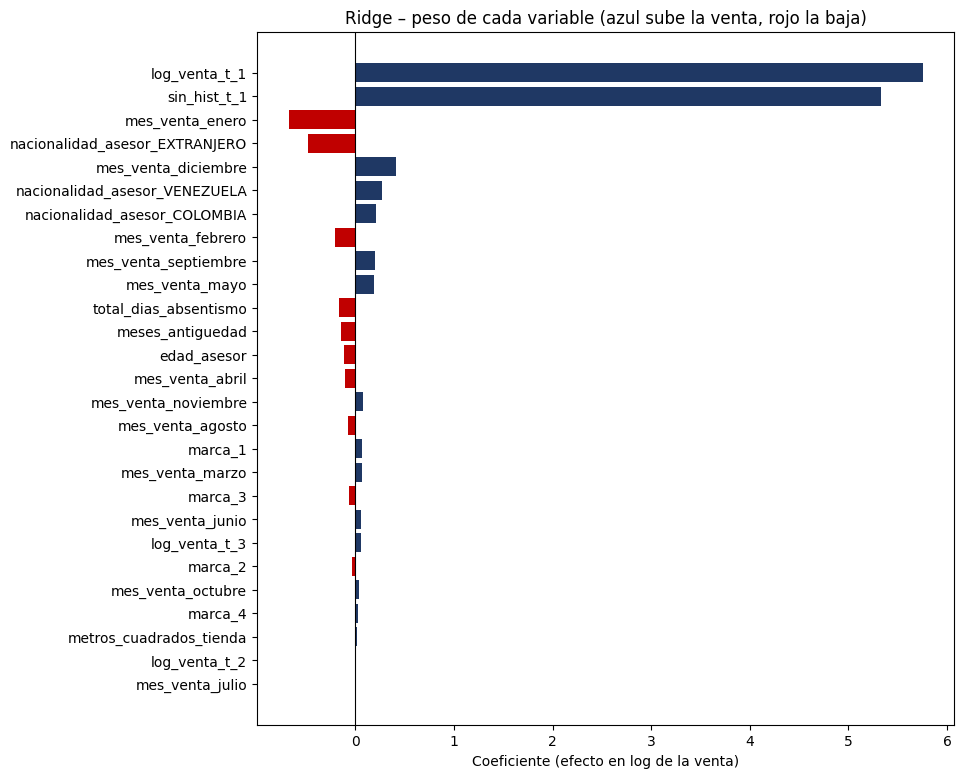

Intercepto (punto de partida, en log): 16.71


In [8]:
# 5.7 Visualización de la regresión Ridge (coeficientes)
pipe_ridge = grid_ridge.best_estimator_.regressor_  # Pipeline de Ridge ya entrenado
nombres_r = [n.split('__', 1)[1]
             for n in pipe_ridge.named_steps['prep'].get_feature_names_out()]
coef = pd.Series(pipe_ridge.named_steps['modelo'].coef_, index=nombres_r)   # Peso de cada variable
coef = coef.reindex(coef.abs().sort_values().index)  # Ordena por tamaño del efecto (sin signo)

fig, ax = plt.subplots(figsize=(9, 9))
colores = ['#C00000' if v < 0 else '#1F3864' for v in coef]   # Rojo = baja la venta; azul = la sube
ax.barh(coef.index, coef.values, color=colores)
ax.axvline(0, color='black', lw=0.8)                 # Línea del cero
ax.set_xlabel('Coeficiente (efecto en log de la venta)')
ax.set_title('Ridge – peso de cada variable (azul sube la venta, rojo la baja)')
fig.savefig(os.path.join(RUTA_SALIDAS, 'coeficientes_ridge.png'), dpi=110, bbox_inches='tight')
plt.show()
print('Intercepto (punto de partida, en log):', round(pipe_ridge.named_steps['modelo'].intercept_, 3))

## 5.8 Modelo 2: árbol de regresión

,max_depth,min_samples_leaf,MAE train,MAE validación,Ranking
12,10,20,"15,161,887.15","18,539,359.08",1
15,12,20,"14,782,250.51","18,644,439.27",2
18,15,20,"14,621,554.32","18,715,157.02",3
9,8,20,"15,894,245.09","18,829,673.49",4
19,15,50,"16,203,023.89","18,843,277.77",5


Mejor configuración: {'regressor__modelo__max_depth': 10, 'regressor__modelo__min_samples_leaf': 20}
Tiempo de reentrenamiento del mejor: 0.10 s


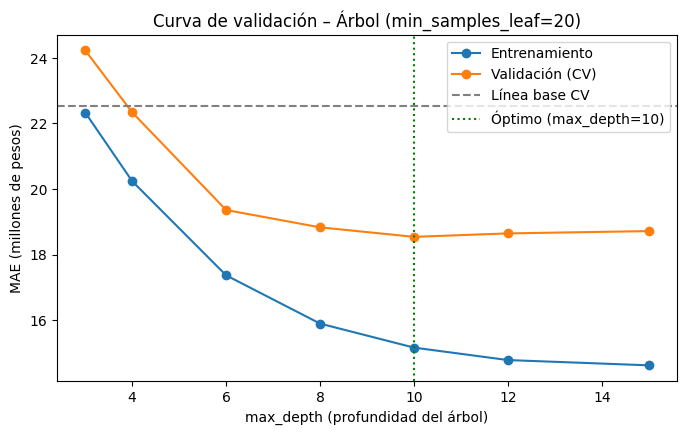

,MAE train,MAE valida,MSE valida,RMSE valida,MAPE % valida,R2 valida
Fold,,,,,,
1,"15,997,859.96","12,265,822.45","348,803,106,547,408.50","18,676,271.22",143.53,0.70
2,"15,152,984.19","16,337,883.45","622,623,810,510,999.50","24,952,430.95",186.28,0.70
3,"15,053,355.40","14,675,225.62","503,324,659,463,491.81","22,434,898.25",169.16,0.66
4,"14,746,909.54","15,733,269.27","606,630,850,859,692.25","24,629,877.20",173.68,0.63
5,"14,858,326.66","33,684,594.61","2,401,106,400,248,709.00","49,001,085.70","4,403.86",0.53


,Árbol: promedio CV
MAE train,"15,161,887.15"
MAE valida,"18,539,359.08"
MSE valida,"896,497,765,526,060.25"
RMSE valida,"27,938,912.66"
MAPE % valida,"1,015.30"
R2 valida,0.64


,MAE train (CV),MAE validación (CV),Brecha %,Desv. entre folds,Línea base CV,Lectura
Árbol,"15,161,887.15","18,539,359.08",22.28,"8,607,955.38","22,536,814.23",SOBREAJUSTE: brecha > 20 %


In [9]:
# 5.8 Modelo 2: árbol de regresión
from sklearn.tree import DecisionTreeRegressor      # Árbol para objetivo continuo
import matplotlib.pyplot as plt                     # Gráficos

grid_arbol = GridSearchCV(
    crear_pipeline(DecisionTreeRegressor(random_state=42), escalar=False),   # Sin escalado
    param_grid={'regressor__modelo__max_depth': [3, 4, 6, 8, 10, 12, 15],     # Niveles de preguntas
                'regressor__modelo__min_samples_leaf': [20, 50, 100]},        # Tamaño mínimo de hoja
    cv=folds, scoring='neg_mean_absolute_error',
    return_train_score=True, n_jobs=-1)
grid_arbol.fit(X_train, y_train)                    # 21 combinaciones × 5 folds

res_arbol = pd.DataFrame(grid_arbol.cv_results_)[
    ['param_regressor__modelo__max_depth', 'param_regressor__modelo__min_samples_leaf',
     'mean_train_score', 'mean_test_score', 'rank_test_score']]
res_arbol[['mean_train_score', 'mean_test_score']] *= -1          # MAE en positivo
res_arbol.columns = ['max_depth', 'min_samples_leaf', 'MAE train', 'MAE validación', 'Ranking']
display(res_arbol.sort_values('Ranking').head(5))  # Las 5 mejores combinaciones
print('Mejor configuración:', grid_arbol.best_params_)
print(f'Tiempo de reentrenamiento del mejor: {grid_arbol.refit_time_:.2f} s')

# ---- Curva de validación: MAE vs. max_depth (con el mejor min_samples_leaf) ----
hoja = grid_arbol.best_params_['regressor__modelo__min_samples_leaf']
mejor = grid_arbol.best_params_['regressor__modelo__max_depth']
curva = res_arbol[res_arbol['min_samples_leaf'] == hoja].sort_values('max_depth')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curva['max_depth'], curva['MAE train'] / 1e6, marker='o', label='Entrenamiento')
ax.plot(curva['max_depth'], curva['MAE validación'] / 1e6, marker='o', label='Validación (CV)')
ax.axhline(MAE_LINEA_BASE_CV / 1e6, color='gray', ls='--', label='Línea base CV')
ax.axvline(mejor, color='green', ls=':', label=f'Óptimo (max_depth={mejor})')
ax.set_xlabel('max_depth (profundidad del árbol)'); ax.set_ylabel('MAE (millones de pesos)')
ax.set_title(f'Curva de validación – Árbol (min_samples_leaf={hoja})'); ax.legend()
fig.savefig(os.path.join(RUTA_SALIDAS, 'curva_validacion_arbol.png'), dpi=120, bbox_inches='tight')
plt.show()

cv_arbol = evaluar_cv(grid_arbol.best_estimator_)  # Todas las métricas por fold
display(cv_arbol)
display(cv_arbol.mean().to_frame('Árbol: promedio CV'))
diagnostico(cv_arbol, 'Árbol')                      # 🩺 Diagnóstico

In [10]:
# 5.8 A Ajuste por sobreajuste: mejor combinación con brecha ≤ 20 %
res_arbol['Brecha %'] = (res_arbol['MAE validación'] - res_arbol['MAE train']) / res_arbol['MAE train'] * 100
display(res_arbol.sort_values('MAE validación').round(2))   # Las 21 combinaciones con su brecha

aceptables = res_arbol[res_arbol['Brecha %'] <= UMBRAL_BRECHA]      # Solo las que no sobreajustan
elegida = aceptables.sort_values('MAE validación').iloc[0]          # La más precisa entre ellas
print(f"Elegida: max_depth={int(elegida['max_depth'])}, min_samples_leaf={int(elegida['min_samples_leaf'])}")

arbol_final = clone(grid_arbol.best_estimator_).set_params(          # Mismo Pipeline, nueva configuración
    regressor__modelo__max_depth=int(elegida['max_depth']),
    regressor__modelo__min_samples_leaf=int(elegida['min_samples_leaf']))

t0 = time.time(); arbol_final.fit(X_train, y_train)                 # Reentrena con todo el entrenamiento
print(f'Tiempo de entrenamiento: {time.time() - t0:.2f} s')         # Para la tabla del formato

cv_arbol = evaluar_cv(arbol_final)                  # Métricas por fold de la configuración elegida
display(cv_arbol)
display(cv_arbol.mean().to_frame('Árbol ajustado: promedio CV'))
diagnostico(cv_arbol, 'Árbol ajustado')             # 🩺 Debe decir BUEN AJUSTE

,max_depth,min_samples_leaf,MAE train,MAE validación,Ranking,Brecha %
12,10,20,"15,161,887.15","18,539,359.08",1,22.28
15,12,20,"14,782,250.51","18,644,439.27",2,26.13
18,15,20,"14,621,554.32","18,715,157.02",3,28.00
9,8,20,"15,894,245.09","18,829,673.49",4,18.47
19,15,50,"16,203,023.89","18,843,277.77",5,16.29
16,12,50,"16,219,023.74","18,845,080.09",6,16.19
13,10,50,"16,282,746.76","18,864,673.87",7,15.86
10,8,50,"16,631,690.30","18,953,988.88",8,13.96
17,12,100,"17,512,166.67","19,335,663.30",9,10.41
20,15,100,"17,512,166.67","19,335,663.30",9,10.41


Elegida: max_depth=8, min_samples_leaf=20
Tiempo de entrenamiento: 0.09 s


,MAE train,MAE valida,MSE valida,RMSE valida,MAPE % valida,R2 valida
Fold,,,,,,
1,"16,780,884.32","11,561,419.76","323,450,195,025,362.19","17,984,721.16",131.77,0.73
2,"15,784,025.69","16,814,771.67","690,519,763,779,583.12","26,277,742.75",173.47,0.66
3,"15,646,260.29","15,250,817.78","533,391,826,651,028.56","23,095,277.15",152.76,0.63
4,"15,633,596.50","16,028,938.75","640,123,050,970,652.62","25,300,653.17",173.26,0.61
5,"15,626,458.64","34,492,419.47","2,521,841,144,044,265.50","50,217,936.48","4,466.14",0.51


,Árbol ajustado: promedio CV
MAE train,"15,894,245.09"
MAE valida,"18,829,673.49"
MSE valida,"941,865,196,094,178.38"
RMSE valida,"28,575,266.14"
MAPE % valida,"1,019.48"
R2 valida,0.63


,MAE train (CV),MAE validación (CV),Brecha %,Desv. entre folds,Línea base CV,Lectura
Árbol ajustado,"15,894,245.09","18,829,673.49",18.47,"8,984,170.47","22,536,814.23",BUEN AJUSTE


Profundidad: 8 | Hojas (grupos finales): 153


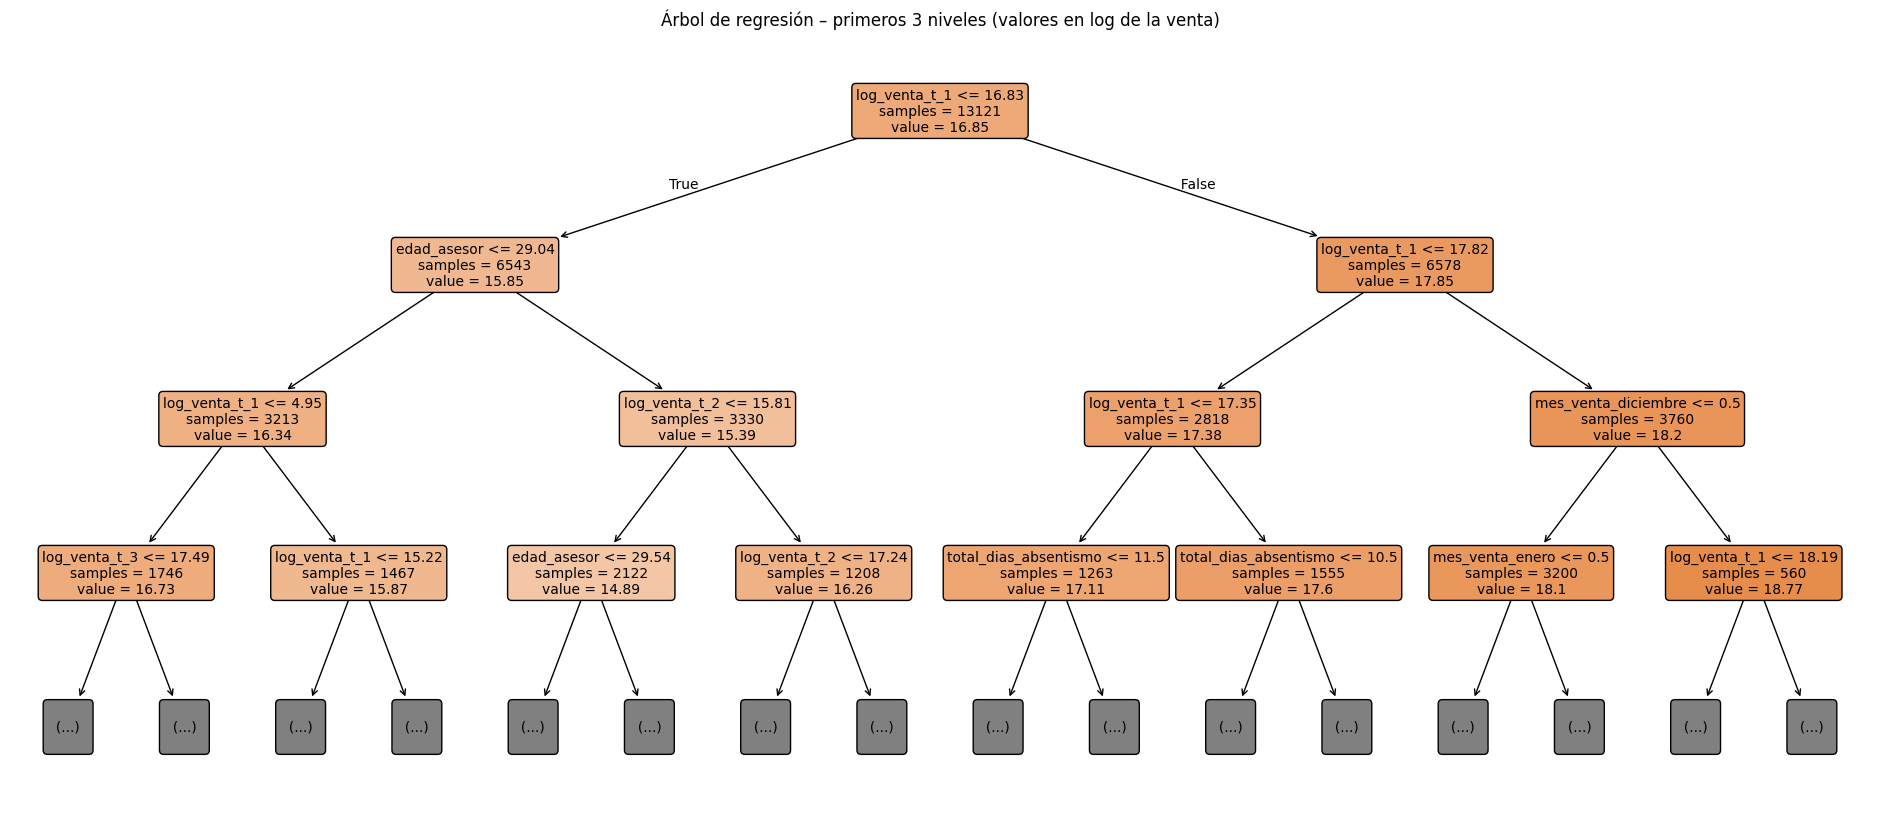

,Valor en log,Venta en pesos
0,15.00,"3,269,016"
1,16.00,"8,886,110"
2,17.00,"24,154,952"
3,17.50,"39,824,783"
4,18.00,"65,659,968"
5,19.00,"178,482,300"


In [11]:
# 5.8 B Visualización del árbol (primeros 3 niveles)
from sklearn.tree import plot_tree                  # Dibuja árboles de scikit-learn

pipe_arbol = arbol_final.regressor_                  # Pipeline ya entrenado dentro del modelo
nombres = [n.split('__', 1)[1]                       # Nombres de columnas tras la preparación
           for n in pipe_arbol.named_steps['prep'].get_feature_names_out()]   # 'num__edad' → 'edad'
arbol = pipe_arbol.named_steps['modelo']             # El árbol en sí
print('Profundidad:', arbol.get_depth(), '| Hojas (grupos finales):', arbol.get_n_leaves())

fig, ax = plt.subplots(figsize=(24, 10))            # Lienzo grande para que se lea
plot_tree(arbol, max_depth=3,                       # Solo los 3 primeros niveles
          feature_names=nombres, filled=True, rounded=True,   # Colores: más oscuro = venta mayor
          impurity=False, precision=2, fontsize=10, ax=ax)
ax.set_title('Árbol de regresión – primeros 3 niveles (valores en log de la venta)')
fig.savefig(os.path.join(RUTA_SALIDAS, 'arbol_regresion.png'), dpi=110, bbox_inches='tight')
plt.show()

ref = pd.DataFrame({'Valor en log': [15, 16, 17, 17.5, 18, 19]})   # Tabla para traducir log → pesos
ref['Venta en pesos'] = np.expm1(ref['Valor en log']).map('{:,.0f}'.format)
ref

## 5.9 Modelo 3: Random Forest

Tiempo total del GridSearch: 3.7 min


,max_depth,min_samples_leaf,max_features,MAE train,MAE validación,Ranking,Brecha %
14,20,10,0.50,"13,508,666.16","17,018,270.33",1,25.98
10,14,10,0.50,"13,621,035.71","17,055,211.03",2,25.21
6,10,10,0.50,"14,349,243.51","17,213,249.58",3,19.96
7,10,30,0.50,"16,033,062.23","18,061,104.73",4,12.65
15,20,30,0.50,"15,932,311.76","18,088,282.03",5,13.53
11,14,30,0.50,"15,936,881.31","18,105,255.69",6,13.61
12,20,10,sqrt,"15,868,283.27","18,759,962.24",7,18.22
8,14,10,sqrt,"16,001,959.61","18,814,656.65",8,17.58
2,6,10,0.50,"17,228,749.06","19,262,915.48",9,11.81
4,10,10,sqrt,"16,924,933.97","19,446,599.13",10,14.90


Elegida: max_depth=10, min_samples_leaf=10, max_features=0.5
Tiempo de entrenamiento: 6.14 s


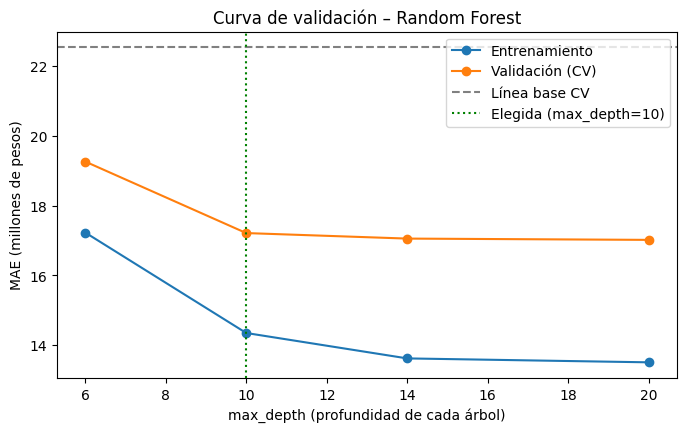

,MAE train,MAE valida,MSE valida,RMSE valida,MAPE % valida,R2 valida
Fold,,,,,,
1,"15,006,447.31","10,740,852.96","295,076,200,903,075.19","17,177,782.19",108.82,0.75
2,"14,379,632.94","16,684,524.87","665,009,082,390,070.25","25,787,770.02",166.76,0.68
3,"14,273,022.53","13,122,177.58","437,541,080,195,605.19","20,917,482.64",130.53,0.70
4,"14,058,338.97","14,214,451.26","543,545,548,449,262.12","23,314,063.32",162.80,0.67
5,"14,028,775.81","31,304,241.23","2,104,563,514,500,204.75","45,875,521.95","4,486.37",0.59


,Random Forest: promedio CV
MAE train,"14,349,243.51"
MAE valida,"17,213,249.58"
MSE valida,"809,147,085,287,643.62"
RMSE valida,"26,614,524.02"
MAPE % valida,"1,011.05"
R2 valida,0.68


,MAE train (CV),MAE validación (CV),Brecha %,Desv. entre folds,Línea base CV,Lectura
Random Forest,"14,349,243.51","17,213,249.58",19.96,"8,161,758.01","22,536,814.23",BUEN AJUSTE


In [12]:
# 5.9 Modelo 3: Random Forest
from sklearn.ensemble import RandomForestRegressor  # Bosque aleatorio para objetivo continuo

p = 'regressor__modelo__'                           # Prefijo de los hiperparámetros dentro del Pipeline
grid_rf = GridSearchCV(
    crear_pipeline(RandomForestRegressor(n_estimators=200,   # 200 árboles
                                         random_state=42,    # Semilla
                                         n_jobs=1),          # 1 núcleo por bosque; GridSearch reparte el resto
                   escalar=False),
    param_grid={p + 'max_depth': [6, 10, 14, 20],
                p + 'min_samples_leaf': [10, 30],
                p + 'max_features': ['sqrt', 0.5]},
    cv=folds, scoring='neg_mean_absolute_error',
    return_train_score=True, n_jobs=-1)             # Varias combinaciones en paralelo
t0 = time.time(); grid_rf.fit(X_train, y_train)     # 16 combinaciones × 5 folds
print(f'Tiempo total del GridSearch: {(time.time() - t0) / 60:.1f} min')

res_rf = pd.DataFrame(grid_rf.cv_results_)[
    ['param_' + p + 'max_depth', 'param_' + p + 'min_samples_leaf', 'param_' + p + 'max_features',
     'mean_train_score', 'mean_test_score', 'rank_test_score']]
res_rf[['mean_train_score', 'mean_test_score']] *= -1               # MAE en positivo
res_rf.columns = ['max_depth', 'min_samples_leaf', 'max_features', 'MAE train', 'MAE validación', 'Ranking']
res_rf['Brecha %'] = (res_rf['MAE validación'] - res_rf['MAE train']) / res_rf['MAE train'] * 100
display(res_rf.sort_values('MAE validación').round(2))              # Las 16 combinaciones

elegida = res_rf[res_rf['Brecha %'] <= UMBRAL_BRECHA].sort_values('MAE validación').iloc[0]   # Mejor sin sobreajuste
print(f"Elegida: max_depth={int(elegida['max_depth'])}, min_samples_leaf={int(elegida['min_samples_leaf'])}, "
      f"max_features={elegida['max_features']}")
rf_final = clone(grid_rf.best_estimator_).set_params(
    **{p + 'max_depth': int(elegida['max_depth']),
       p + 'min_samples_leaf': int(elegida['min_samples_leaf']),
       p + 'max_features': elegida['max_features']})
t0 = time.time(); rf_final.fit(X_train, y_train)
print(f'Tiempo de entrenamiento: {time.time() - t0:.2f} s')

# ---- Curva de validación: MAE vs. max_depth (con los demás parámetros de la elegida) ----
curva = res_rf[(res_rf['min_samples_leaf'] == elegida['min_samples_leaf']) &
               (res_rf['max_features'] == elegida['max_features'])].sort_values('max_depth')
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curva['max_depth'], curva['MAE train'] / 1e6, marker='o', label='Entrenamiento')
ax.plot(curva['max_depth'], curva['MAE validación'] / 1e6, marker='o', label='Validación (CV)')
ax.axhline(MAE_LINEA_BASE_CV / 1e6, color='gray', ls='--', label='Línea base CV')
ax.axvline(int(elegida['max_depth']), color='green', ls=':', label=f"Elegida (max_depth={int(elegida['max_depth'])})")
ax.set_xlabel('max_depth (profundidad de cada árbol)'); ax.set_ylabel('MAE (millones de pesos)')
ax.set_title('Curva de validación – Random Forest'); ax.legend()
fig.savefig(os.path.join(RUTA_SALIDAS, 'curva_validacion_rf.png'), dpi=120, bbox_inches='tight')
plt.show()

cv_rf = evaluar_cv(rf_final)                        # Métricas por fold (entrena 5 bosques más)
display(cv_rf)
display(cv_rf.mean().to_frame('Random Forest: promedio CV'))
diagnostico(cv_rf, 'Random Forest')                 # 🩺 Diagnóstico

Árboles en el bosque: 200


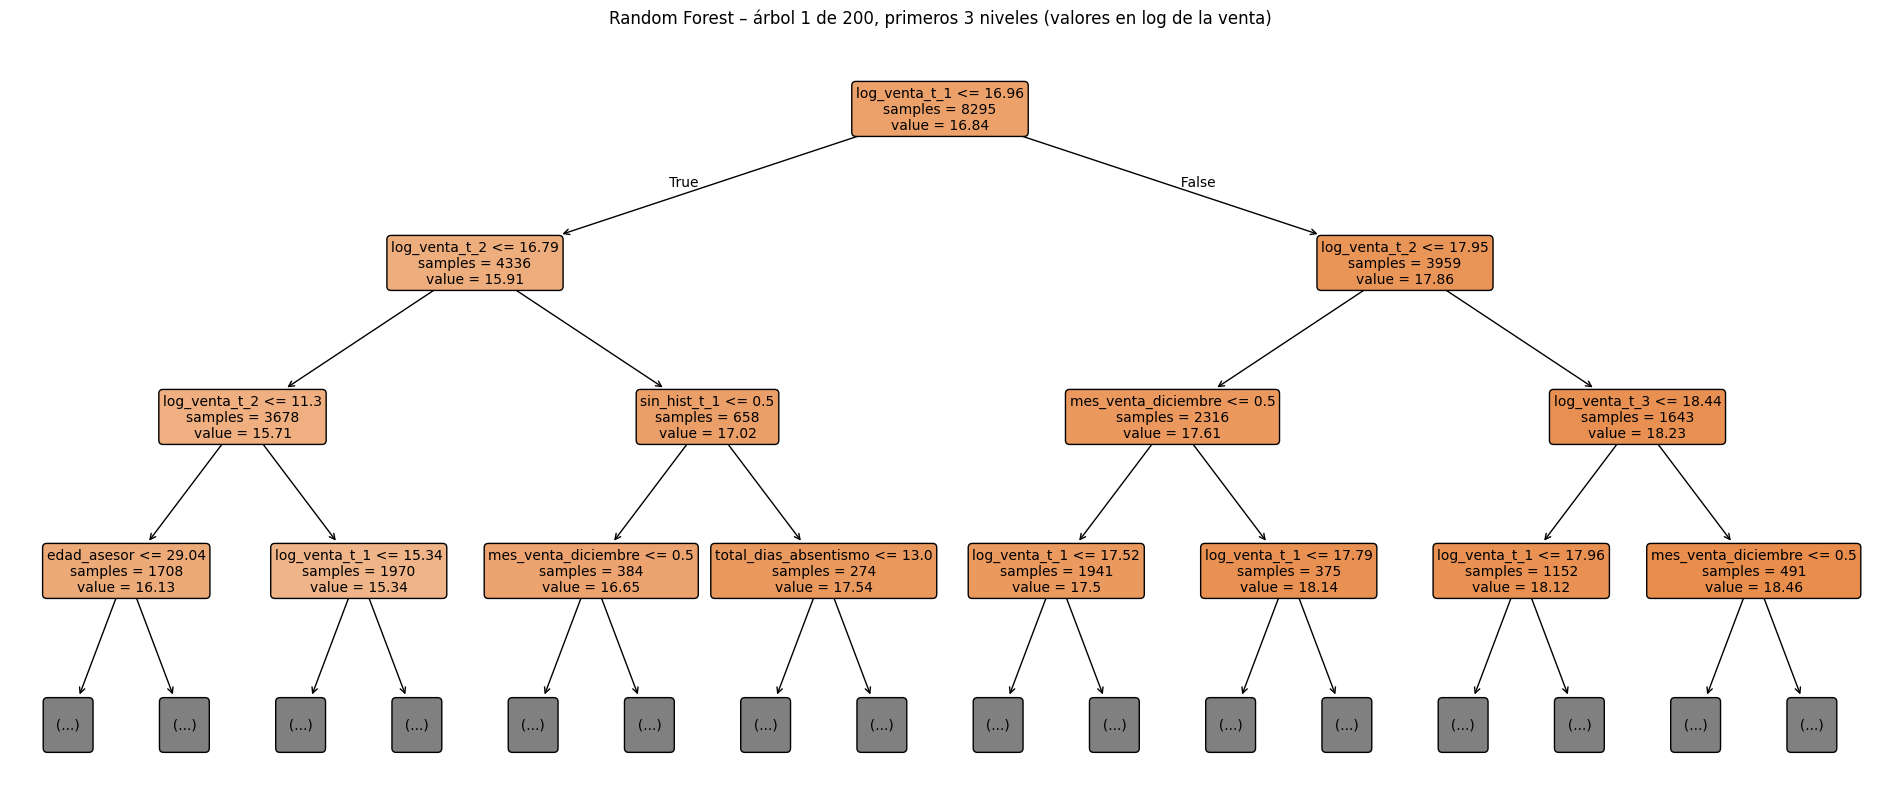

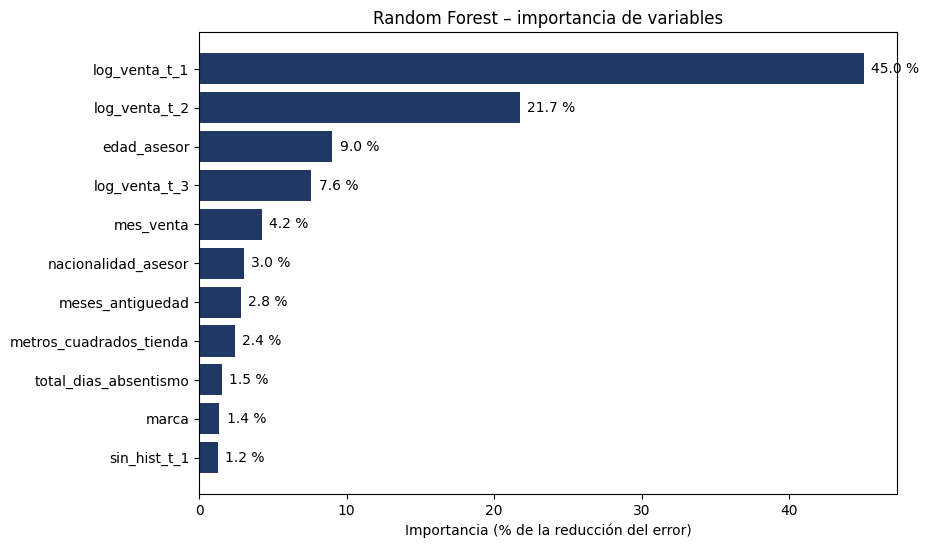

,Importancia %
log_venta_t_1,45.00
log_venta_t_2,21.70
edad_asesor,9.00
log_venta_t_3,7.60
mes_venta,4.20
nacionalidad_asesor,3.00
meses_antiguedad,2.80
metros_cuadrados_tienda,2.40
total_dias_absentismo,1.50
marca,1.40


In [13]:
# 5.9 A Visualización del Random Forest
pipe_rf = rf_final.regressor_                       # Pipeline entrenado dentro del modelo
nombres_rf = [n.split('__', 1)[1]                   # Nombres de columnas tras la preparación
              for n in pipe_rf.named_steps['prep'].get_feature_names_out()]
bosque = pipe_rf.named_steps['modelo']              # El bosque (200 árboles)
print('Árboles en el bosque:', len(bosque.estimators_))

# ---- (1) Un árbol del bosque, como ejemplo (primeros 3 niveles) ----
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(bosque.estimators_[0], max_depth=3,       # Árbol n.° 1 de 200
          feature_names=nombres_rf, filled=True, rounded=True,
          impurity=False, precision=2, fontsize=10, ax=ax)
ax.set_title('Random Forest – árbol 1 de 200, primeros 3 niveles (valores en log de la venta)')
fig.savefig(os.path.join(RUTA_SALIDAS, 'rf_arbol_ejemplo.png'), dpi=110, bbox_inches='tight')
plt.show()

# ---- (2) Importancia de variables en todo el bosque ----
imp = pd.Series(bosque.feature_importances_, index=nombres_rf)          # Importancia por columna
def variable_original(nombre):                      # 'mes_venta_diciembre' → 'mes_venta'
    for c in CATEGORICAS:
        if nombre.startswith(c + '_'):
            return c
    return nombre
imp_var = imp.groupby(imp.index.map(variable_original)).sum().sort_values()   # Suma las dummies

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(imp_var.index, imp_var.values * 100, color='#1F3864')
for i, v in enumerate(imp_var.values * 100):        # Etiqueta con el % en cada barra
    ax.text(v + 0.5, i, f'{v:.1f} %', va='center')
ax.set_xlabel('Importancia (% de la reducción del error)')
ax.set_title('Random Forest – importancia de variables')
fig.savefig(os.path.join(RUTA_SALIDAS, 'importancia_variables.png'), dpi=110, bbox_inches='tight')
plt.show()
(imp_var.sort_values(ascending=False) * 100).round(1).to_frame('Importancia %')

## 5.10 Criterio de selección (definido ANTES de evaluar en 2026)
1. Supera la línea base en validación cruzada.
2. Menor MAE en validación cruzada.
3. Brecha entrenamiento – validación ≤ 20 % (criterio del proyecto).
4. Si dos modelos difieren menos de 5 % en MAE, se elige el más simple.

| Modelo | MAE CV | Brecha | ¿Cumple? |
|---|---|---|---|
| Ridge | 20,36 M | 7,0 % | Sí, pero no es el menor |
| Árbol (prof. 8) | 18,83 M | 18,5 % | Sí, pero no es el menor |
| **Random Forest** | **17,21 M** | **19,96 %** | **Sí: menor MAE, 8,6 % mejor que el árbol (> 5 %)** |

**Modelo seleccionado: Random Forest** (200 árboles, max_depth=10, min_samples_leaf=10, max_features=0,5). A partir de aquí no se modifica.

In [14]:
# 5.10 Comparación de todos los modelos con todas las métricas
modelos = {'Ridge': grid_ridge.best_estimator_,     # Versiones entrenadas solo con 2024–2025
           'Árbol': arbol_final,
           'Random Forest': rf_final}
cvs = {'Ridge': cv_ridge, 'Árbol': cv_arbol, 'Random Forest': cv_rf}   # Resultados por fold (Fase 7)

# ---- Tabla A: validación cruzada (decide la selección) ----
filas_a = {'Línea base': {**resumen_folds[['MAE', 'MSE', 'RMSE', 'MAPE %', 'R2']].mean().to_dict(),
                          'Brecha %': np.nan, 'Tiempo (s)': np.nan}}
for nombre, cv in cvs.items():
    t0 = time.time(); clone(modelos[nombre]).fit(X_train, y_train)   # Mide el tiempo de aprendizaje
    tiempo = time.time() - t0
    filas_a[nombre] = {'MAE': cv['MAE valida'].mean(), 'MSE': cv['MSE valida'].mean(),
                       'RMSE': cv['RMSE valida'].mean(), 'MAPE %': cv['MAPE % valida'].mean(),
                       'R2': cv['R2 valida'].mean(),
                       'Brecha %': (cv['MAE valida'].mean() - cv['MAE train'].mean()) / cv['MAE train'].mean() * 100,
                       'Tiempo (s)': tiempo}
tabla_cv = pd.DataFrame(filas_a).T                   # Una fila por modelo
print('A. VALIDACIÓN CRUZADA TEMPORAL (2024–2025) — base de la selección')
display(tabla_cv)

# ---- Tabla B: prueba 2026 (solo informativa) ----
filas_b = {'Línea base': linea_base_test}
for nombre, modelo in modelos.items():
    filas_b[nombre] = metricas(y_test, modelo.predict(X_test))   # Cada modelo predice 2026
tabla_test = pd.DataFrame(filas_b).T
print('B. PRUEBA 2026)')
display(tabla_test)

A. VALIDACIÓN CRUZADA TEMPORAL (2024–2025) — base de la selección


,MAE,MSE,RMSE,MAPE %,R2,Brecha %,Tiempo (s)
Línea base,"22,536,814.23","1,364,872,081,900,314.00","34,485,306.28",312.98,0.45,NaN,NaN
Ridge,"20,359,149.83","1,049,940,848,280,184.38","30,976,055.63",943.92,0.55,7.01,0.03
Árbol,"18,829,673.49","941,865,196,094,178.38","28,575,266.14","1,019.48",0.63,18.47,0.12
Random Forest,"17,213,249.58","809,147,085,287,643.62","26,614,524.02","1,011.05",0.68,19.96,7.09


B. PRUEBA 2026)


,MAE,MSE,RMSE,MAPE %,R2,Excluidos MAPE (venta=0)
Línea base,"26,309,922.57","1,998,999,189,235,131.50","44,710,168.75",485.64,-0.08,12.00
Ridge,"20,541,268.54","1,061,067,887,735,558.75","32,574,037.02",513.16,0.42,12.00
Árbol,"16,805,565.30","718,222,573,454,672.25","26,799,674.88",867.96,0.61,12.00
Random Forest,"15,668,156.43","649,301,098,596,448.75","25,481,387.30",525.16,0.65,12.00


## 5.11 Examen final: ¿cuánto se equivoca el Random Forest con datos que nunca vio (2026)?
**Qué estoy haciendo:** le pido al modelo ganador, entrenado solo con 2024–2025, que prediga la venta de cada asesor en enero–agosto 2026, y comparo con lo que realmente vendieron.
**Para qué:** medir su desempeño real (como pasaría en la vida real) y compararlo con la línea base ("vende lo mismo que el mes anterior"). Se hace una sola vez; el resultado no se usa para cambiar el modelo.
**Qué espero ver:** la tabla Random Forest vs. línea base con las 5 métricas, el % de mejora y el error promedio por cada mes de 2026.

In [15]:
# 5.11 EXAMEN FINAL – Predicción del Random Forest sobre 2026 y comparación con la línea base
pred_test = rf_final.predict(X_test)                # Predicción en pesos para los 4.482 registros de 2026
m_rf_test = metricas(y_test, pred_test)             # Métricas del Random Forest en 2026

comparacion = pd.DataFrame({'Línea base': linea_base_test,        # Calculada en la Celda 6.3
                            'Random Forest': m_rf_test})
display(comparacion)
mejora = (1 - m_rf_test['MAE'] / linea_base_test['MAE']) * 100    # % de reducción del error
print(f"MAE 2026 → Random Forest: {m_rf_test['MAE']:,.0f} | Línea base: {linea_base_test['MAE']:,.0f} "
      f"| Mejora: {mejora:.1f} %")

# ¿En qué mes de 2026 se equivoca más el modelo? (solo lectura, no cambia nada)
por_mes = (pd.DataFrame({'mes': test['mes_venta'].astype(str),
                         'error_rf': (y_test - pred_test).abs(),                 # Error del modelo
                         'error_base': (y_test - test['venta_t_1']).abs()})     # Error de la línea base
             .groupby('mes', sort=False).mean())
por_mes.columns = ['MAE Random Forest', 'MAE línea base']
por_mes

,Línea base,Random Forest
MAE,"26,309,922.57","15,668,156.43"
MSE,"1,998,999,189,235,131.50","649,301,098,596,448.75"
RMSE,"44,710,168.75","25,481,387.30"
MAPE %,485.64,525.16
R2,-0.08,0.65
Excluidos MAPE (venta=0),12.00,12.00


MAE 2026 → Random Forest: 15,668,156 | Línea base: 26,309,923 | Mejora: 40.4 %


,MAE Random Forest,MAE línea base
mes,,
febrero,"12,465,462.18","16,935,513.42"
marzo,"17,268,590.43","21,234,054.20"
abril,"14,799,924.34","18,535,887.34"
mayo,"20,442,578.01","21,389,872.65"
junio,"14,537,632.82","20,425,405.01"
julio,"16,179,530.78","19,229,842.84"
agosto,"14,927,514.31","21,022,327.55"
enero,"14,927,205.38","62,012,351.11"


## 5.12 Diagnóstico visual del examen: ¿dónde acierta y dónde se equivoca el modelo?
**Qué estoy haciendo:** dibujo dos gráficos con las predicciones de 2026.
- Real vs. predicho: cada punto es un asesor-mes; si el modelo fuera perfecto, todos caerían sobre la diagonal roja. Se usan ejes logarítmicos porque las ventas van de miles a cientos de millones.
- Residuos (real − predicho): muestra si el modelo tiende a quedarse corto (arriba de 0) o a pasarse (abajo de 0).
**Para qué:** detectar patrones de error, por ejemplo si falla más con los asesores que venden mucho o poco.
**Qué espero ver:** una nube de puntos cerca de la diagonal y residuos repartidos alrededor de 0. Ambos gráficos se guardan en Drive.

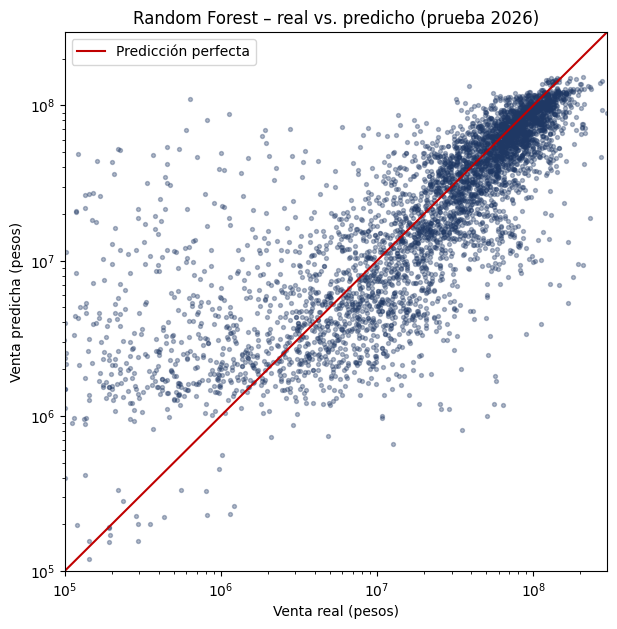

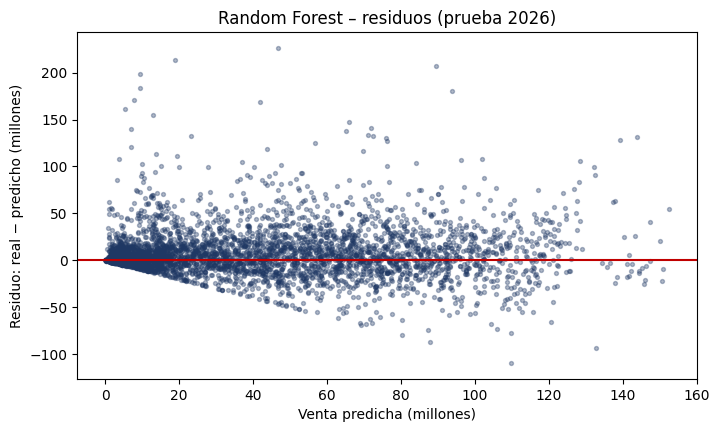

Residuo promedio: 6,862,288 (positivo = en promedio subestima; negativo = sobreestima)


In [16]:
# 5.12 GRÁFICOS DEL EXAMEN – Real vs. predicho y residuos del Random Forest en 2026
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_test, pred_test, s=8, alpha=0.35, color='#1F3864')    # Cada punto = un asesor-mes de 2026
lim = [max(1e5, min(y_test[y_test > 0].min(), pred_test.min())), max(y_test.max(), pred_test.max())]
ax.plot(lim, lim, color='#C00000', lw=1.5, label='Predicción perfecta')   # Diagonal de referencia
ax.set_xscale('log'); ax.set_yscale('log')          # Escala log: ventas muy distintas en tamaño
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel('Venta real (pesos)'); ax.set_ylabel('Venta predicha (pesos)')
ax.set_title('Random Forest – real vs. predicho (prueba 2026)'); ax.legend()
fig.savefig(os.path.join(RUTA_SALIDAS, 'real_vs_predicho.png'), dpi=110, bbox_inches='tight')
plt.show()

residuos = y_test - pred_test                       # Positivo = el modelo se quedó corto
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(pred_test / 1e6, residuos / 1e6, s=8, alpha=0.35, color='#1F3864')
ax.axhline(0, color='#C00000', lw=1.5)              # Línea de error cero
ax.set_xlabel('Venta predicha (millones)'); ax.set_ylabel('Residuo: real − predicho (millones)')
ax.set_title('Random Forest – residuos (prueba 2026)')
fig.savefig(os.path.join(RUTA_SALIDAS, 'residuos.png'), dpi=110, bbox_inches='tight')
plt.show()
print(f'Residuo promedio: {residuos.mean():,.0f} (positivo = en promedio subestima; negativo = sobreestima)')

## 5.12 Modelo de producción: reentrenar con TODA la base (abr-2024 a ago-2026) y guardarlo
**Qué estoy haciendo:** entreno de nuevo el Random Forest, con exactamente la misma configuración, pero ahora con los 17.603 registros, incluido 2026.

In [17]:
# 5.12 MODELO DE PRODUCCIÓN – Reentrenamiento con toda la base para guardarlo como modelo_final.joblib
X_total, y_total = base[PREDICTORES], base[OBJETIVO]   # 17.603 registros (2024 a agosto 2026)
modelo_produccion = clone(rf_final)                  # Misma configuración, sin entrenar
t0 = time.time(); modelo_produccion.fit(X_total, y_total)
print(f'Reentrenado con {len(X_total):,} registros en {time.time() - t0:.1f} s')

ruta_modelo = os.path.join(RUTA_SALIDAS, 'modelo_final.joblib')
joblib.dump(modelo_produccion, ruta_modelo, compress=3)   # Guarda el Pipeline completo (preparación + modelo)
tamano_mb = os.path.getsize(ruta_modelo) / 1024**2
print(f'modelo_final.joblib: {tamano_mb:.1f} MB')
print('✅ Apto para GitHub web (< 25 MB)' if tamano_mb < 25 else
      '⚠️ Supera 25 MB: habrá que reducir n_estimators o max_depth')

Reentrenado con 17,603 registros en 8.0 s
modelo_final.joblib: 3.4 MB
✅ Apto para GitHub web (< 25 MB)


## 5.13 Prueba adicional para verificar que el archivo guardado predice igual que el modelo en memoria
**Qué estoy haciendo:** abro modelo_final.joblib (igual que lo hará la app), predigo 3 casos con el modelo en memoria y con el del archivo, y verifico que den exactamente lo mismo.

In [18]:
# 5.13 PRUEBA ADICIONAL Recargar el modelo guardado, predecir 3 casos y guardarlos para verificar posteriormente
modelo_cargado = joblib.load(ruta_modelo)           # Abre el archivo, como lo hará la app

casos = X_test.sample(3, random_state=42)           # 3 casos al azar (siempre los mismos: random_state=42)
pred_memoria = modelo_produccion.predict(casos)     # Predicción del modelo en memoria
pred_archivo = modelo_cargado.predict(casos)        # Predicción del modelo recargado desde el archivo
print('¿Coinciden?:', np.allclose(pred_memoria, pred_archivo))   # Esperado: True

casos_app = casos.copy()
for k in (1, 2, 3):                                 # Ventas anteriores en pesos (lo que se digita en la app)
    casos_app[f'venta_t_{k}'] = np.expm1(casos_app[f'log_venta_t_{k}']).round(0)
casos_app['venta_estimada'] = pred_archivo.round(0)
casos_app.to_csv(os.path.join(RUTA_SALIDAS, 'casos_prueba_app.csv'), index=False)   # Casos de control para la Fase 12
casos_app[['edad_asesor', 'nacionalidad_asesor', 'marca', 'mes_venta',
           'venta_t_1', 'venta_t_2', 'venta_t_3', 'venta_estimada']]

¿Coinciden?: True


,edad_asesor,nacionalidad_asesor,marca,mes_venta,venta_t_1,venta_t_2,venta_t_3,venta_estimada
157,31.00,COLOMBIA,3,enero,"107,837,875.00","79,340,334.00","53,753,678.00","37,942,924.00"
3970,31.00,COLOMBIA,2,mayo,"123,715,980.00","134,061,959.00","96,632,554.00","114,246,130.00"
1018,21.00,COLOMBIA,2,agosto,0.00,0.00,0.00,"18,943,880.00"
